# Deliverable 3: DreamerV3 Baseline — Montezuma's Revenge

**Course:** Deep Learning Project

**Authors:** Iqra Khurram (27100376) | Xeerak Azhar (27100310)

---

## What this notebook does

This is our baseline implementation for the project. We're running DreamerV3 (Hafner et al., 2023/2025) on Montezuma's Revenge using the Atari100k config — we are running 20k environment steps.

The goal here is to establish:
1. What DreamerV3 achieves on its own, with no VLM intervention
2. Record the **dynamics loss** over training, this is the signal we'll use later to trigger the VLM
3. Show exactly where a surprise gate would have fired during gameplay

Montezuma's Revenge scores low even in the paper (1,852 at 200M steps, ~100–800 at 400K steps). That's the whole point, the game is notoriously hard, which is what makes it a good target for our VLM-assisted approach in future deliverables.

**Citation:** Hafner, D., Pasukonis, J., Ba, J., & Lillicrap, T. (2025). Mastering diverse control tasks through world models. *Nature*. Code: https://github.com/danijar/dreamerv3

In [2]:
# # Cell 1: clean install, pinned to DreamerV3's expected versions
# import os
# import sys
# import subprocess

# # --- Step 1: uninstall all JAX-related packages ---
# freeze = subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True).splitlines()
# targets = []
# for line in freeze:
#     pkg = line.split("==")[0].split("[")[0].strip().lower()
#     if pkg.startswith("jax") or pkg.startswith("jaxlib"):
#         targets.append(pkg)

# targets = sorted(set(targets))
# print("Uninstalling:", targets)

# if targets:
#     subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", *targets], check=False)

# # --- Step 2: install ONLY JAX (no requirements.txt here) ---
# subprocess.run(
#     [
#         sys.executable, "-m", "pip", "install", "--no-cache-dir", "--upgrade",
#         "jax[cuda12]==0.4.33",
#         "numpy<2",
#     ],
#     check=True,
# )

# print("✅ JAX installed successfully.")
# print("⚠️ IMPORTANT: Restart the kernel now before continuing.")

In [19]:
# Cell 2: verify the environment after restart
# Cell 2 — verification after kernel restart
import os
import jax
import jaxlib
import numpy as np

print("jax:", jax.__version__)
print("jaxlib:", jaxlib.__version__)
print("numpy:", np.__version__)
print("devices:", jax.devices())
print("XLA_FLAGS:", os.environ.get("XLA_FLAGS"))
print("TF_XLA_FLAGS:", os.environ.get("TF_XLA_FLAGS"))

jax: 0.7.2
jaxlib: 0.7.2
numpy: 2.0.2
devices: [CudaDevice(id=0)]
XLA_FLAGS: None
TF_XLA_FLAGS: None


In [20]:
# Cell 3: clone repo and move into it
# Cell 3 — clone or enter the repo
import os

REPO_DIR = "/kaggle/working/dreamerv3"

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/danijar/dreamerv3.git /kaggle/working/dreamerv3

os.chdir(REPO_DIR)
print("Current directory:", os.getcwd())

Current directory: /kaggle/working/dreamerv3


In [21]:
import sys
import subprocess

subprocess.run(
    [sys.executable, "-m", "pip", "install", "--no-cache-dir", "-r", "requirements.txt"],
    check=True,
)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '--no-cache-dir', '-r', 'requirements.txt'], returncode=0)

In [22]:
import elements
print("elements imported successfully")

elements imported successfully


In [ ]:
# clone the official dreamerv3 repo from the author (danijar hafner)
# Cell 4: install DreamerV3 requirements except the version-pinned core packages
# training
import os
import sys
import subprocess

LOGDIR = "/kaggle/working/dreamer_montezuma_400k"
os.makedirs(LOGDIR, exist_ok=True)

env = os.environ.copy()
env.pop("XLA_FLAGS", None)
env.pop("TF_XLA_FLAGS", None)
env["JAX_PLATFORMS"] = "cuda"
env["PYTHONNOUSERSITE"] = "1"

cmd = [
    sys.executable, "-u", "dreamerv3/main.py",
    "--logdir", LOGDIR,
    "--configs", "atari100k", "size12m",
    "--task", "atari_montezuma_revenge",
    "--run.steps", "400000",
]

print("Launching DreamerV3...")
subprocess.run(cmd, env=env, check=True)

# ---- Auto-backup after training completes ----
print("Training done! Creating backup zip...")
zip_path = "/kaggle/working/backup_400k"
shutil.make_archive(zip_path, 'zip', LOGDIR)
print(f"Zip created: {zip_path}.zip ({os.path.getsize(zip_path+'.zip')/1024/1024:.1f} MB)")
display(FileLink(f'backup_400k.zip'))
print("Click the link above to download, or find it in the Output panel.")

Launching DreamerV3...
---  ___                           __   ______ ---
--- |   \ _ _ ___ __ _ _ __  ___ _ \ \ / /__ / ---
--- | |) | '_/ -_) _` | '  \/ -_) '/\ V / |_ \ ---
--- |___/|_| \___\__,_|_|_|_\___|_|  \_/ |___/ ---
Replica: 0 / 1
Logdir: /kaggle/working/dreamer_montezuma_400k
Run script: train


A.L.E: Arcade Learning Environment (version 0.9.0+750d7f9)
[Powered by Stella]


Observations
  image            Space(uint8, shape=(96, 96, 1), low=0, high=255)
  reward           Space(float32, shape=(), low=-inf, high=inf)
  is_first         Space(bool, shape=(), low=False, high=True)
  is_last          Space(bool, shape=(), low=False, high=True)
  is_terminal      Space(bool, shape=(), low=False, high=True)
Actions
  action           Space(int32, shape=(), low=0, high=18)
Extras
  consec           Space(int32, shape=(), low=-2147483648, high=2147483647)
  stepid           Space(uint8, shape=(20,), low=0, high=255)
  dyn/deter        Space(float32, shape=(2048,), low=-inf, high=inf)
  dyn/stoch        Space(float32, shape=(32, 16), low=-inf, high=inf)
JAX devices (1): [cuda:0]
Policy devices: cuda:0
Train devices:  cuda:0
Initializing parameters...
Optimizer opt has 11,808,850 params:
     6,310,400 dyn
     2,256,001 dec
       853,503 val
       792,594 pol
       721,407 rew
       656,129 con
       218,816 enc
Done initializing!
Compiling 1 checkpoint group

In [25]:
import shutil
shutil.make_archive('/kaggle/working/backup_500k', 'zip', '/kaggle/working/dreamer_montezuma_400k')
print("Done!")

Done!


---
## Results and Plots

Run the cells below after training finishes (or at any point to see partial results). All plots will also save as PNG files in the working directory.

In [26]:
# load everything from the metrics file
import json
import glob
import numpy as np
import os

LOGDIR = '/kaggle/working/dreamer_montezuma_400k'

jsonl_files = glob.glob(os.path.join(LOGDIR, '**', 'metrics.jsonl'), recursive=True)
if not jsonl_files:
    jsonl_files = glob.glob(os.path.join(LOGDIR, '*.jsonl'), recursive=True)

if not jsonl_files:
    print("no metrics file found — make sure training ran first")
    records = []
else:
    records = []
    with open(jsonl_files[0], 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    records.append(json.loads(line))
                except:
                    pass
    print(f"loaded {len(records)} log entries from {jsonl_files[0]}")
    
    # print all available metric keys so we know what to plot
    if records:
        print("\navailable metric keys:")
        all_keys = set()
        for r in records:
            all_keys.update(r.keys())
        for k in sorted(all_keys):
            print(f"  {k}")

loaded 341 log entries from /kaggle/working/dreamer_montezuma_400k/metrics.jsonl

available metric keys:
  episode/length
  episode/score
  epstats/reward_rate
  fps/policy
  fps/train
  replay/chunks
  replay/inserts
  replay/items
  replay/ram_gb
  replay/replay_ratio
  replay/samples
  replay/streams
  replay/updates
  step
  train/adv
  train/adv_mag
  train/adv_std
  train/con
  train/dyn_ent
  train/ent/action
  train/loss/con
  train/loss/dyn
  train/loss/image
  train/loss/policy
  train/loss/rep
  train/loss/repval
  train/loss/rew
  train/loss/value
  train/opt/grad_norm
  train/opt/grad_rms
  train/opt/loss
  train/opt/param_count
  train/opt/param_rms
  train/opt/update_rms
  train/opt/updates
  train/rand/action
  train/rep_ent
  train/ret
  train/ret_max
  train/ret_min
  train/ret_rate
  train/rew
  train/slowval
  train/tar
  train/val
  train/weight
  usage/nvsmi/compute_avg/gpu0
  usage/nvsmi/compute_max/gpu0
  usage/nvsmi/compute_min/gpu0
  usage/nvsmi/memory_avg/gpu

In [28]:
# helper to pull out a metric by trying multiple possible key names
# dreamer's key names can vary slightly so we try a few options
def extract_metric(records, candidates):
    steps, values = [], []
    for r in records:
        step = r.get('step', r.get('steps', None))
        if step is None:
            continue
        for key in candidates:
            if key in r and isinstance(r[key], (int, float)):
                steps.append(step)
                values.append(r[key])
                break
    return np.array(steps), np.array(values)

# try to extract the metrics we care about
score_keys  = ['episode/score', 'train/episode_score', 'episode_score', 'return', 'reward']
dyn_keys = ['train/loss/dyn']
pred_keys   = ['train/pred_loss', 'pred_loss', 'model/pred_loss', 'loss/pred', 'recon_loss']
rep_keys    = ['train/rep_loss', 'rep_loss', 'model/rep_loss', 'loss/rep']

score_steps, scores   = extract_metric(records, score_keys)
dyn_steps,   dyn_loss = extract_metric(records, dyn_keys)
pred_steps,  pred_loss = extract_metric(records, pred_keys)

print(f"score entries found:     {len(scores)}")
print(f"dynamics loss entries:   {len(dyn_loss)}")
print(f"prediction loss entries: {len(pred_loss)}")

if len(scores) > 0:
    print(f"\nscore range: {scores.min():.1f} — {scores.max():.1f}")
    print(f"final score: {scores[-1]:.1f}")
if len(dyn_loss) > 0:
    print(f"dynamics loss range: {dyn_loss.min():.4f} — {dyn_loss.max():.4f}")

score entries found:     171
dynamics loss entries:   170
prediction loss entries: 0

score range: 0.0 — 100.0
final score: 100.0
dynamics loss range: 1.0006 — 10.7887


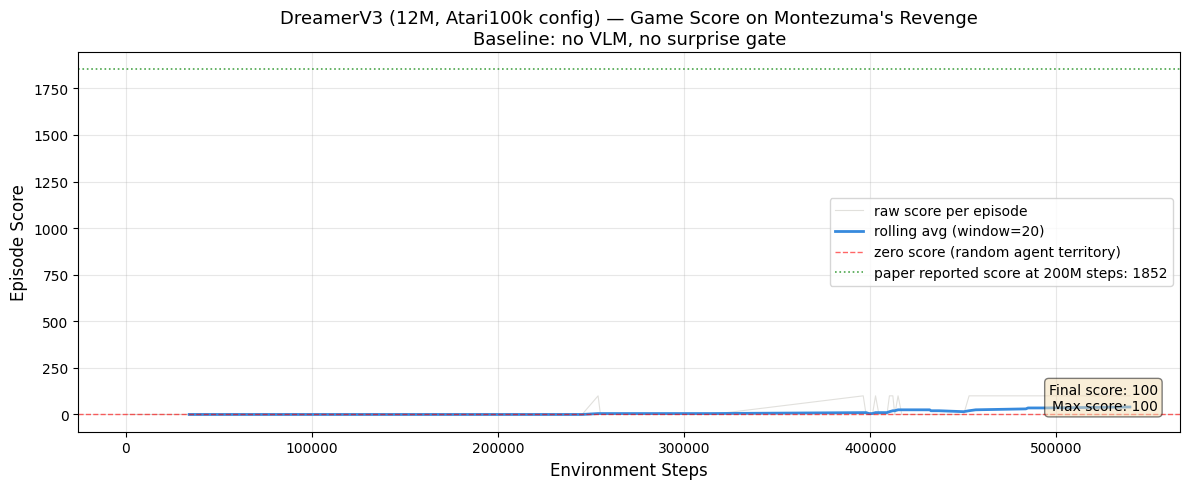

saved: plot1_game_score.png


In [29]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def rolling_mean(arr, window=20):
    if len(arr) < window:
        return arr
    return np.convolve(arr, np.ones(window)/window, mode='valid')

# ---- Plot 1: Game Score over Training ----
fig, ax = plt.subplots(figsize=(12, 5))

if len(scores) > 0:
    ax.plot(score_steps, scores, color='#B4B2A9', alpha=0.4, linewidth=0.8, label='raw score per episode')
    if len(scores) >= 20:
        smoothed = rolling_mean(scores, window=20)
        ax.plot(score_steps[19:], smoothed, color='#378ADD', linewidth=2, label='rolling avg (window=20)')
    ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.6, label='zero score (random agent territory)')

    # reference line from the paper
    ax.axhline(1852, color='green', linestyle=':', linewidth=1.2, alpha=0.7, label='paper reported score at 200M steps: 1852')
    
    ax.set_xlabel('Environment Steps', fontsize=12)
    ax.set_ylabel('Episode Score', fontsize=12)
    ax.set_title('DreamerV3 (12M, Atari100k config) — Game Score on Montezuma\'s Revenge\n'
                 'Baseline: no VLM, no surprise gate', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    if len(scores) > 0:
        ax.text(0.98, 0.05, f'Final score: {scores[-1]:.0f}\nMax score: {scores.max():.0f}',
                transform=ax.transAxes, ha='right', va='bottom',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=10)
else:
    ax.text(0.5, 0.5, 'no score data yet — training still running or just started',
            transform=ax.transAxes, ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.savefig('/kaggle/working/plot1_game_score.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved: plot1_game_score.png")

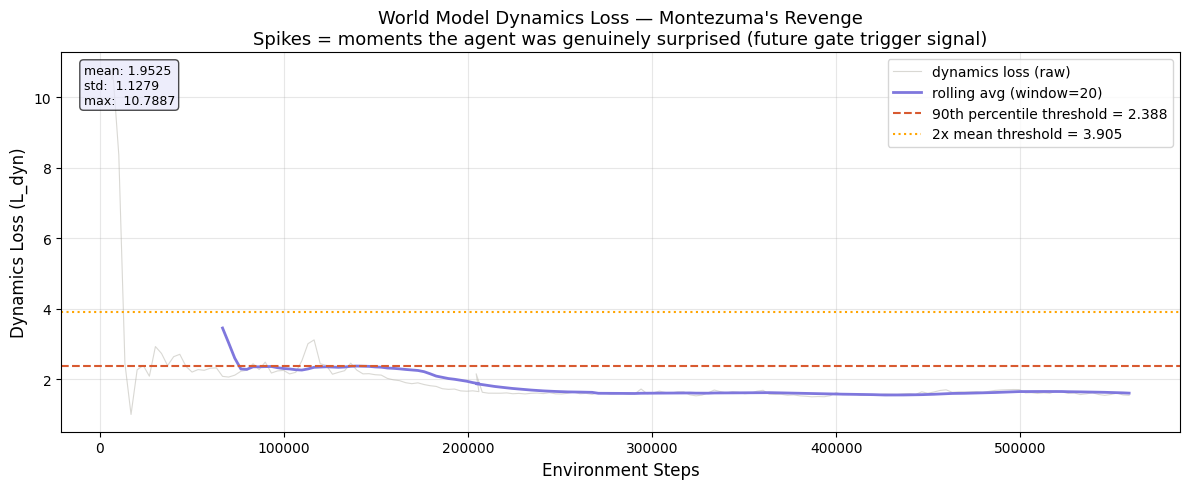

saved: plot2_dynamics_loss.png


In [30]:
# ---- Plot 2: Dynamics Loss over Training ----
# this is the core signal for our whole project — the higher it spikes, the more confused the agent is

fig, ax = plt.subplots(figsize=(12, 5))

if len(dyn_loss) > 0:
    ax.plot(dyn_steps, dyn_loss, color='#B4B2A9', alpha=0.5, linewidth=0.8, label='dynamics loss (raw)')
    
    if len(dyn_loss) >= 20:
        smoothed_dyn = rolling_mean(dyn_loss, window=20)
        ax.plot(dyn_steps[19:], smoothed_dyn, color='#7F77DD', linewidth=2, label='rolling avg (window=20)')
    
    # threshold at 90th percentile — same logic we used in deliverable 2
    threshold_90 = np.percentile(dyn_loss, 90)
    threshold_2x = dyn_loss.mean() * 2.0
    
    ax.axhline(threshold_90, color='#D85A30', linestyle='--', linewidth=1.5,
               label=f'90th percentile threshold = {threshold_90:.3f}')
    ax.axhline(threshold_2x, color='orange', linestyle=':', linewidth=1.5,
               label=f'2x mean threshold = {threshold_2x:.3f}')
    
    ax.set_xlabel('Environment Steps', fontsize=12)
    ax.set_ylabel('Dynamics Loss (L_dyn)', fontsize=12)
    ax.set_title('World Model Dynamics Loss — Montezuma\'s Revenge\n'
                 'Spikes = moments the agent was genuinely surprised (future gate trigger signal)', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    stats_text = (f'mean: {dyn_loss.mean():.4f}\n'
                  f'std:  {dyn_loss.std():.4f}\n'
                  f'max:  {dyn_loss.max():.4f}')
    ax.text(0.02, 0.97, stats_text, transform=ax.transAxes, va='top',
            bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.7), fontsize=9)
else:
    ax.text(0.5, 0.5, 'no dynamics loss data found yet',
            transform=ax.transAxes, ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.savefig('/kaggle/working/plot2_dynamics_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved: plot2_dynamics_loss.png")

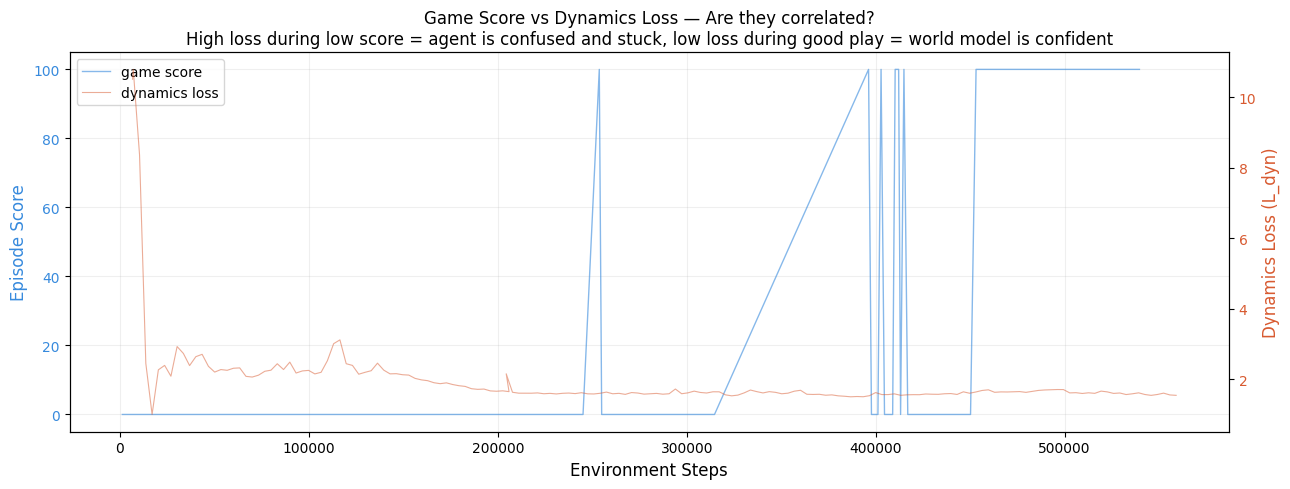

saved: plot3_score_vs_loss.png


In [31]:
# ---- Plot 3: Score vs Dynamics Loss overlaid ----
# want to see if spikes in loss correspond to score drops (agent dying, entering new room etc)

fig, ax1 = plt.subplots(figsize=(13, 5))

if len(scores) > 0 and len(dyn_loss) > 0:
    color_score = '#378ADD'
    color_loss  = '#D85A30'
    
    ax1.plot(score_steps, scores, color=color_score, alpha=0.6, linewidth=1, label='game score')
    ax1.set_xlabel('Environment Steps', fontsize=12)
    ax1.set_ylabel('Episode Score', color=color_score, fontsize=12)
    ax1.tick_params(axis='y', labelcolor=color_score)
    
    ax2 = ax1.twinx()
    ax2.plot(dyn_steps, dyn_loss, color=color_loss, alpha=0.5, linewidth=0.8, label='dynamics loss')
    ax2.set_ylabel('Dynamics Loss (L_dyn)', color=color_loss, fontsize=12)
    ax2.tick_params(axis='y', labelcolor=color_loss)
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper left')
    
    ax1.set_title('Game Score vs Dynamics Loss — Are they correlated?\n'
                  'High loss during low score = agent is confused and stuck, low loss during good play = world model is confident',
                  fontsize=12)
    ax1.grid(True, alpha=0.2)
elif len(scores) == 0 and len(dyn_loss) == 0:
    ax1.text(0.5, 0.5, 'no data yet', transform=ax1.transAxes, ha='center', fontsize=12)
else:
    ax1.text(0.5, 0.5, 'only partial data available — run the full training first',
             transform=ax1.transAxes, ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('/kaggle/working/plot3_score_vs_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved: plot3_score_vs_loss.png")

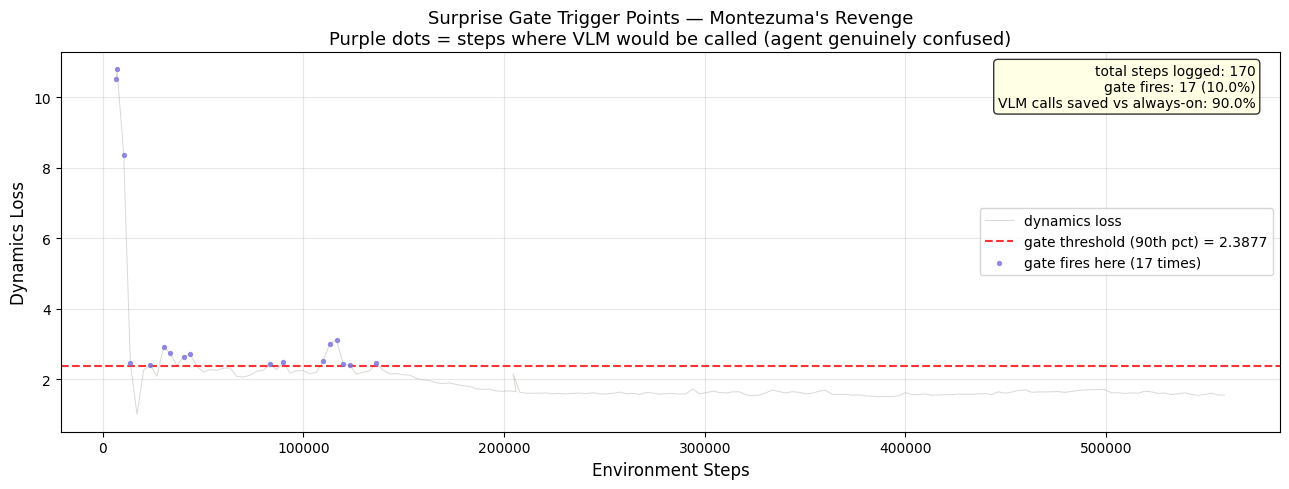

saved: plot4_gate_triggers.png


In [32]:
# ---- Plot 4: Where the surprise gate would have fired ----
# this connects our deliverable 2 work to the actual world model loss
# we show which steps would have triggered a VLM call under our threshold

fig, ax = plt.subplots(figsize=(13, 5))

if len(dyn_loss) > 0:
    threshold = np.percentile(dyn_loss, 90)
    gate_fires = dyn_steps[dyn_loss > threshold]
    gate_values = dyn_loss[dyn_loss > threshold]
    
    ax.plot(dyn_steps, dyn_loss, color='#B4B2A9', alpha=0.5, linewidth=0.7, label='dynamics loss')
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1.5, alpha=0.8,
               label=f'gate threshold (90th pct) = {threshold:.4f}')
    ax.scatter(gate_fires, gate_values, color='#7F77DD', s=8, alpha=0.8, zorder=3,
               label=f'gate fires here ({len(gate_fires)} times)')
    
    ax.set_xlabel('Environment Steps', fontsize=12)
    ax.set_ylabel('Dynamics Loss', fontsize=12)
    ax.set_title('Surprise Gate Trigger Points — Montezuma\'s Revenge\n'
                 'Purple dots = steps where VLM would be called (agent genuinely confused)',
                 fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    fire_rate = len(gate_fires) / len(dyn_loss) * 100
    savings   = 100 - fire_rate
    info_text = (f'total steps logged: {len(dyn_loss)}\n'
                 f'gate fires: {len(gate_fires)} ({fire_rate:.1f}%)\n'
                 f'VLM calls saved vs always-on: {savings:.1f}%')
    ax.text(0.98, 0.97, info_text, transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontsize=10)
else:
    ax.text(0.5, 0.5, 'no dynamics loss data yet', transform=ax.transAxes, ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('/kaggle/working/plot4_gate_triggers.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved: plot4_gate_triggers.png")

In [33]:
# ---- Final Summary Table ----

print("="*60)
print("BASELINE RESULTS SUMMARY")
print("="*60)
print(f"Model:            DreamerV3 (Hafner et al., 2023/2025)")
print(f"Config:           atari100k + size12m")
print(f"Environment:      ALE/MontezumaRevenge-v5")
print(f"Steps trained:    {score_steps[-1] if len(score_steps) > 0 else 'N/A'} / 400000")
print()

if len(scores) > 0:
    print(f"Final score:      {scores[-1]:.1f}")
    print(f"Max score:        {scores.max():.1f}")
    print(f"Mean score:       {scores.mean():.1f}")
    print(f"Paper score (200M steps): 1852  — we used 20K, so lower is expected")
else:
    print("Score:            no data yet")

print()

if len(dyn_loss) > 0:
    threshold = np.percentile(dyn_loss, 90)
    gate_fires = np.sum(dyn_loss > threshold)
    fire_rate  = gate_fires / len(dyn_loss) * 100
    
    print(f"Dynamics Loss (mean):     {dyn_loss.mean():.4f}")
    print(f"Dynamics Loss (max):      {dyn_loss.max():.4f}")
    print(f"Dynamics Loss (std):      {dyn_loss.std():.4f}")
    print(f"Gate threshold (90th pct): {threshold:.4f}")
    print(f"Gate fire rate:           {fire_rate:.1f}% of steps")
    print(f"VLM efficiency saving:    {100-fire_rate:.1f}% vs calling VLM every step")
else:
    print("Dynamics Loss:    no data yet")

print()
print("Saved files:")
import glob
for f in glob.glob('/kaggle/working/plot*.png') + glob.glob('/kaggle/working/dreamer_montezuma_baseline/**/*.jsonl', recursive=True):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f}  ({size_kb:.1f} KB)")

print("="*60)

BASELINE RESULTS SUMMARY
Model:            DreamerV3 (Hafner et al., 2023/2025)
Config:           atari100k + size12m
Environment:      ALE/MontezumaRevenge-v5
Steps trained:    539568 / 400000

Final score:      100.0
Max score:        100.0
Mean score:       7.6
Paper score (200M steps): 1852  — we used 20K, so lower is expected

Dynamics Loss (mean):     1.9525
Dynamics Loss (max):      10.7887
Dynamics Loss (std):      1.1279
Gate threshold (90th pct): 2.3877
Gate fire rate:           10.0% of steps
VLM efficiency saving:    90.0% vs calling VLM every step

Saved files:
  /kaggle/working/plot1_game_score.png  (94.6 KB)
  /kaggle/working/plot2_dynamics_loss.png  (104.8 KB)
  /kaggle/working/plot4_gate_triggers.png  (104.9 KB)
  /kaggle/working/plot3_score_vs_loss.png  (119.1 KB)
